# Preprocesado financiero: shrinkage + denoising con detoning opcional

Este notebook prepara las entradas de los modelos aplicando una limpieza de la matriz de covarianzas, siguiendo la idea vista en el taller de preprocesado financiero.

## Idea general

La matriz de covarianzas estimada con datos históricos contiene dos partes mezcladas:

1. **Señal real**: relaciones entre activos que pueden ser relativamente estables.
2. **Ruido**: relaciones que aparecen en la muestra histórica, pero que pueden no mantenerse en el futuro.

Si entrenamos un modelo directamente con retornos sin filtrar, parte de lo que aprende puede ser ruido. El objetivo de este notebook es crear unas entradas más estables antes de entrenar los modelos.

## Pasos del preprocesado

1. **Shrinkage con Ledoit-Wolf**: estima una matriz de covarianzas más estable que la covarianza histórica simple.
2. **Denoising con Marchenko-Pastur**: separa autovalores que parecen señal de autovalores que parecen ruido y suaviza la parte ruidosa.
3. **Detoning opcional**: permite eliminar el primer componente principal, que suele representar el factor mercado. En este notebook se deja como opción, porque eliminar el factor mercado puede reducir ruido común, pero también puede eliminar información útil para predecir retornos.

## Resultado esperado

El resultado de este preprocesado no son retornos originales puros, sino **features transformadas**. Estas features tienen el mismo número de columnas que los activos originales, pero cada columna puede ser una combinación lineal de varios activos. Se usan como variables de entrada del modelo.

La salida `y` se mantiene como retornos reales originales, porque el objetivo sigue siendo predecir retornos futuros reales.

## 1. Imports

Se importan las librerías necesarias para descargar datos, ajustar Ledoit-Wolf y aplicar denoising.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os

import yfinance as yf

from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler

# KernelDensity se usa para estimar el autovalor maximo de ruido
# ajustando una densidad teorica de Marchenko-Pastur a los autovalores empiricos.
from sklearn.neighbors import KernelDensity
from scipy.optimize import minimize

warnings.simplefilter(action="ignore", category=FutureWarning)

print("Imports cargados correctamente.")

Imports cargados correctamente.


## 2. Descarga de datos

Misma lógica que en los notebooks anteriores: precios de cierre ajustados de los 23 activos y se eliminan columnas con NaN.

In [2]:
# ============================================================
# DESCARGA DE DATOS
# ============================================================

start_date = "1945-01-01"

tickers_validos = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED",
    "GD", "GE", "HON", "HPQ", "IBM", "IP", "JNJ", "KO",
    "KR", "MMM", "MO", "MRK", "MSI", "PG", "XOM"
]

#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)["Close"]
#precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close = pd.read_csv('precios_diferenciados.csv', header=0, index_col=0)

# Eliminamos activos con valores faltantes para tener un panel rectangular.
precios_close.dropna(axis=1, inplace=True)

print("Dimensiones de precios_close:", precios_close.shape)
precios_close.head()

Dimensiones de precios_close: (14734, 23)


,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1967-10-12,0.000462,0.008276,0.025994,0.008784,0.020056,0.013291,0.007139,0.007168,0.015415,0.021511,...,0.008847,0.010252,0.007323,0.000648,0.047321,0.000223,0.012362,0.059310,0.006084,0.006135
1967-10-13,0.013570,0.011212,0.024166,0.004614,0.024460,0.014986,0.011336,0.005446,0.008580,0.050912,...,0.016976,0.015295,0.005987,0.000738,0.041003,0.000265,0.012046,0.107520,0.007585,0.008133
1967-10-16,0.016903,0.007884,0.012848,-0.000722,0.017335,0.020077,0.007223,0.007209,0.011685,0.030600,...,0.016026,0.012367,0.007715,0.000772,0.032796,0.000198,0.012799,0.148054,0.013284,0.004940
1967-10-17,0.016459,0.032319,0.026737,0.005858,0.012638,0.016868,0.008961,0.007128,0.005108,0.054862,...,0.008239,0.011451,0.005220,0.000957,0.041474,0.000243,0.007551,0.149666,0.012850,0.003788
1967-10-18,0.023481,0.040379,0.026255,0.003843,0.011821,0.012016,0.009581,0.007188,0.019202,0.054408,...,0.013750,0.009411,0.005603,0.000905,0.030321,0.000305,0.010205,0.151617,0.010866,0.003628


## 3. Retornos logarítmicos



In [4]:
# ============================================================
# RETORNOS LOGARITMICOS
# ============================================================

returns = np.log(precios_close).diff().dropna()

print("Dimensiones de returns:", returns.shape)
returns.head()

Dimensiones de returns: (16190, 23)


,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


## 4. Configuración de ventanas



In [ ]:
# ============================================================
# CONFIGURACION DE VENTANAS
# ============================================================

input_window_size = 30
output_window_size = 90

print(f"Ventana de entrada: {input_window_size} dias")
print(f"Ventana de salida:  {output_window_size} dias")

Ventana de entrada: 30 dias
Ventana de salida:  90 dias


## 5. Split temporal único

- 72% inicial: train.
- Siguiente 18%: validación.
- 10% final: test.

Ledoit-Wolf se ajusta solo con las fechas que caen estrictamente en train.

In [ ]:
# ============================================================
# SPLIT TEMPORAL UNICO POR FECHAS
# ============================================================

n_obs = len(returns)

# Indices de corte sobre el eje temporal de returns.
train_end_idx = int(n_obs * 0.72)
val_end_idx   = int(n_obs * 0.90)

train_dates = returns.index[:train_end_idx]
val_dates   = returns.index[train_end_idx:val_end_idx]
test_dates  = returns.index[val_end_idx:]

returns_train = returns.loc[train_dates]
returns_val   = returns.loc[val_dates]
returns_test  = returns.loc[test_dates]

print(f"returns_train: {returns_train.shape}  | {train_dates[0].date()} -> {train_dates[-1].date()}")
print(f"returns_val:   {returns_val.shape}  | {val_dates[0].date()} -> {val_dates[-1].date()}")
print(f"returns_test:  {returns_test.shape}  | {test_dates[0].date()} -> {test_dates[-1].date()}")

returns_train: (11664, 23)  | 1962-01-03 -> 2008-05-05
returns_val:   (2916, 23)  | 2008-05-06 -> 2019-12-03
returns_test:  (1620, 23)  | 2019-12-04 -> 2026-05-15


## 6. Funciones de denoising y detoning opcional

Las funciones siguen la lógica de *Machine Learning for Asset Managers*.

**Marchenko-Pastur** permite identificar qué parte del espectro de autovalores puede explicarse por ruido. Si los retornos fueran independientes, los autovalores de la matriz de correlación estarían dentro de un intervalo teórico.

**Denoising**: los autovalores que caen dentro de la zona de ruido se sustituyen por su media. Los autovalores de señal se conservan.

**Detoning opcional**: permite quitar el primer componente principal, que suele estar relacionado con el factor mercado. Se deja como parámetro porque quitarlo puede ser útil para estudiar relaciones específicas entre activos, pero también puede eliminar señal común relevante.


In [5]:
# ============================================================
# FUNCIONES DE DENOISING Y DETONING
# ============================================================

def mp_pdf(var, q, pts):
    """
    Densidad teorica de Marchenko-Pastur evaluada en una rejilla de autovalores.

    var: varianza del ruido (sigma^2).
    q:   ratio T/N (observaciones / activos). Debe ser > 1.
    pts: numero de puntos en la rejilla.
    """
    e_min = var * (1 - (1.0 / q) ** 0.5) ** 2
    e_max = var * (1 + (1.0 / q) ** 0.5) ** 2
    eigenvalues = np.linspace(e_min, e_max, pts)
    pdf = q / (2 * np.pi * var * eigenvalues) * ((e_max - eigenvalues) * (eigenvalues - e_min)) ** 0.5
    return pd.Series(pdf, index=eigenvalues)


def kde_fit(observations, bandwidth=0.01, x=None):
    """
    Estima la densidad empirica de un conjunto de autovalores con KDE.
    Devuelve una Serie indexada por puntos de evaluacion.
    """
    if len(observations.shape) == 1:
        observations = observations.reshape(-1, 1)

    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(observations)

    if x is None:
        x = np.unique(observations).reshape(-1, 1)
    if len(x.shape) == 1:
        x = x.reshape(-1, 1)

    log_prob = kde.score_samples(x)
    return pd.Series(np.exp(log_prob), index=x.flatten())


def mp_error(params, eigenvalues_empirical, q, bandwidth, pts):
    """
    Error cuadratico entre la densidad teorica MP y la KDE empirica.
    Se minimiza sobre `var` para encontrar la varianza de ruido que mejor encaja.
    """
    var = params[0]
    pdf_theoretical = mp_pdf(var, q, pts)
    pdf_empirical = kde_fit(eigenvalues_empirical, bandwidth=bandwidth, x=pdf_theoretical.index.values)
    return np.sum((pdf_empirical - pdf_theoretical) ** 2)


def find_max_eval(eigenvalues, q, bandwidth=0.01, pts=1000):
    """
    Encuentra lambda+ (el mayor autovalor de ruido segun MP) ajustando
    la varianza del ruido que mejor encaja con la densidad empirica.
    """
    result = minimize(mp_error, x0=np.array([0.5]), args=(eigenvalues, q, bandwidth, pts), bounds=((1e-5, 1 - 1e-5),))
    var = result.x[0] if result.success else 1.0
    e_max = var * (1 + (1.0 / q) ** 0.5) ** 2
    return e_max, var


def denoise_correlation(corr, q, bandwidth=0.01):
    """
    Aplica denoising Marchenko-Pastur a una matriz de correlacion.

    1. Descompone corr en autovalores y autovectores.
    2. Estima lambda+ usando MP.
    3. Reemplaza los autovalores < lambda+ por su media.
    4. Reconstruye la matriz y la renormaliza para que la diagonal sea 1.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    # eigh devuelve en orden creciente; los reordenamos en orden decreciente.
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    e_max, var_noise = find_max_eval(eigenvalues, q, bandwidth)

    # Numero de autovalores que se consideran senal (mayores que lambda+).
    n_facts = int((eigenvalues > e_max).sum())

    # Los autovalores de ruido se reemplazan por su media.
    eigenvalues_denoised = eigenvalues.copy()
    if n_facts < len(eigenvalues_denoised):
        eigenvalues_denoised[n_facts:] = eigenvalues_denoised[n_facts:].mean()

    # Reconstruccion de la matriz.
    corr_denoised = eigenvectors @ np.diag(eigenvalues_denoised) @ eigenvectors.T

    # Renormalizamos para que la diagonal sea exactamente 1.
    d = np.sqrt(np.diag(corr_denoised))
    corr_denoised = corr_denoised / np.outer(d, d)

    return corr_denoised, eigenvalues, eigenvalues_denoised, e_max, n_facts


def detone_correlation(corr, n_remove=1):
    """
    Quita los n_remove autovalores mas grandes (factor mercado y similares).
    Reconstruye la matriz solo con los autovalores especificos.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Componente de mercado (los n_remove primeros autovalores).
    market = np.zeros_like(corr)
    for i in range(n_remove):
        v = eigenvectors[:, i:i+1]
        market += eigenvalues[i] * (v @ v.T)

    # Quitamos el componente de mercado.
    corr_detoned = corr - market

    # Renormalizamos para que la diagonal sea 1.
    d = np.sqrt(np.diag(corr_detoned))
    # Floor numerico por si algun elemento de la diagonal queda muy pequeno.
    d = np.maximum(d, 1e-10)
    corr_detoned = corr_detoned / np.outer(d, d)

    return corr_detoned


def cov_to_corr(cov):
    """Convierte covarianza a correlacion."""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    np.fill_diagonal(corr, 1.0)
    return corr, std


def corr_to_cov(corr, std):
    """Reconstruye covarianza a partir de correlacion y vector de desviaciones tipicas."""
    return corr * np.outer(std, std)


print("Funciones de denoising y detoning definidas.")

Funciones de denoising y detoning definidas.


## 7. Ajuste de Ledoit-Wolf + denoising

El procedimiento se ajusta **solo con train**:

1. Ledoit-Wolf sobre `returns_train`.
2. Conversión de covarianza a correlación.
3. Denoising con Marchenko-Pastur.
4. Detoning opcional.
5. Reconstrucción de la covarianza limpia.

Por defecto, `APPLY_DETONING = False`, porque eliminar el factor mercado puede eliminar también señal útil para la predicción. Si se quiere probar una versión más agresiva, basta con cambiarlo a `True`.


In [ ]:
# ============================================================
# AJUSTE DEL PREPROCESADO USANDO SOLO returns_train
# ============================================================

# El detoning se deja como opción.
# False: aplica shrinkage + denoising, pero mantiene el factor mercado.
# True: además elimina el primer componente principal.
APPLY_DETONING = False
N_DETONE_COMPONENTS = 1

# Paso 1: Ledoit-Wolf sobre train.
lw = LedoitWolf()
lw.fit(returns_train.values)
cov_lw = lw.covariance_

print(f"Shrinkage intensity de Ledoit-Wolf: {lw.shrinkage_:.4f}")

# Paso 2: pasamos a correlacion para aplicar denoising en esa escala.
corr_lw, std_lw = cov_to_corr(cov_lw)

# Paso 3: denoising Marchenko-Pastur.
T, N = returns_train.shape
q = T / N

corr_denoised, eigvals_emp, eigvals_denoised, e_max, n_facts = denoise_correlation(corr_lw, q=q, bandwidth=0.01)

print(f"T (observaciones train): {T}")
print(f"N (activos):             {N}")
print(f"q = T/N:                 {q:.2f}")
print(f"lambda+ (umbral ruido):  {e_max:.4f}")
print(f"Autovalores de senal:    {n_facts} de {N}")

# Paso 4: detoning opcional.
# Si APPLY_DETONING=False, usamos la matriz denoised directamente.
if APPLY_DETONING:
    corr_cleaned = detone_correlation(corr_denoised, n_remove=N_DETONE_COMPONENTS)
    preprocessing_label = "Ledoit-Wolf + denoising + detoning"
    print(f"Detoning aplicado: se elimina(n) {N_DETONE_COMPONENTS} componente(s) principal(es).")
else:
    corr_cleaned = corr_denoised.copy()
    preprocessing_label = "Ledoit-Wolf + denoising"
    print("Detoning no aplicado: se conserva el factor mercado.")

# Paso 5: reconstruir la covarianza limpia.
cov_cleaned = corr_to_cov(corr_cleaned, std_lw)

print(f"Covarianza limpia construida con: {preprocessing_label}")


Shrinkage intensity de Ledoit-Wolf: 0.0060
T (observaciones train): 11664
N (activos):             23
q = T/N:                 507.13
lambda+ (umbral ruido):  1.0908
Autovalores de senal:    3 de 23
Detoning no aplicado: se conserva el factor mercado.
Covarianza limpia construida con: Ledoit-Wolf + denoising


## 8. Visualización del denoising

Comparamos los autovalores empíricos con los autovalores después de aplicar denoising. Los autovalores por debajo de `lambda+` se consideran principalmente ruido y se suavizan.

También se muestra la matriz de correlación final utilizada en el preprocesado. Si `APPLY_DETONING = True`, esta matriz incluye detoning. Si está en `False`, solo incluye denoising.


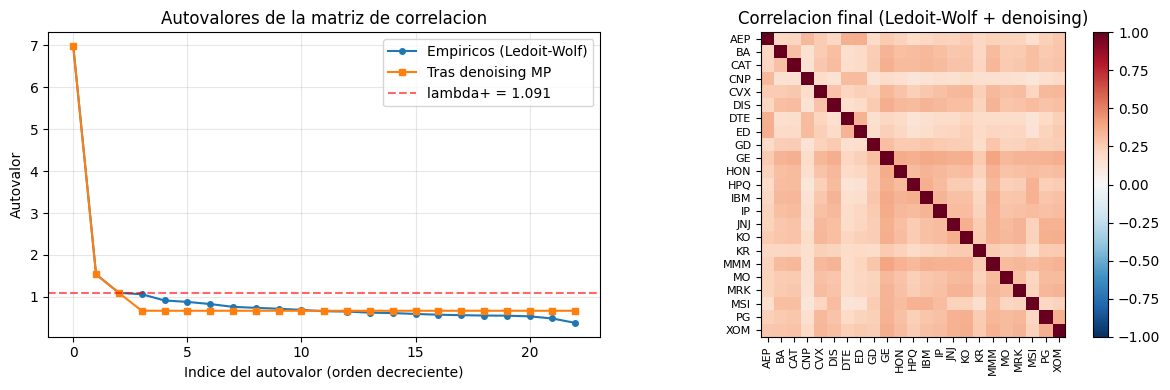

In [ ]:
# ============================================================
# VISUALIZACION: AUTOVALORES ANTES Y DESPUES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: autovalores ordenados.
axes[0].plot(eigvals_emp, "o-", label="Empiricos (Ledoit-Wolf)", markersize=4)
axes[0].plot(eigvals_denoised, "s-", label="Tras denoising MP", markersize=4)
axes[0].axhline(e_max, color="red", linestyle="--", alpha=0.6, label=f"lambda+ = {e_max:.3f}")
axes[0].set_xlabel("Indice del autovalor (orden decreciente)")
axes[0].set_ylabel("Autovalor")
axes[0].set_title("Autovalores de la matriz de correlacion")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Derecha: matriz de correlacion tras denoising + detoning.
im = axes[1].imshow(corr_cleaned, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(f"Correlacion final ({preprocessing_label})")
axes[1].set_xticks(range(N))
axes[1].set_yticks(range(N))
axes[1].set_xticklabels(returns.columns, rotation=90, fontsize=8)
axes[1].set_yticklabels(returns.columns, fontsize=8)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()


## 9. Aplicación de la transformación a los retornos

Tenemos dos matrices:

- `cov_lw`: covarianza estimada con Ledoit-Wolf.
- `cov_cleaned`: covarianza después de denoising y, si se activa, detoning.

Queremos transformar los retornos para que las entradas del modelo tengan una estructura de covarianza más parecida a `cov_cleaned`.

La transformación utilizada es:

$$X_{cleaned} = (X - \mu_{train}) \cdot M$$

con:

$$M = \Sigma_{lw}^{-1/2} \cdot \Sigma_{clean}^{1/2}$$

La media usada para centrar es la media de train, por lo que no se usa información futura.

Una aclaración importante: estas nuevas variables son **features transformadas**, no retornos puros de cada activo. Las columnas mantienen el mismo orden y número que los activos originales, pero cada columna puede mezclar información de varios activos. Esto es normal en este tipo de preprocesado, porque la transformación se basa en la matriz de covarianzas.


In [ ]:
# ============================================================
# CONSTRUCCION DE LA TRANSFORMACION DE COVARIANZA
# ============================================================

def matrix_sqrt(mat):
    """Raiz cuadrada simetrica de una matriz semidefinida positiva."""
    eigvals, eigvecs = np.linalg.eigh(mat)
    eigvals = np.maximum(eigvals, 1e-12)
    return eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T


def matrix_inv_sqrt(mat):
    """Inversa de la raiz cuadrada simetrica."""
    eigvals, eigvecs = np.linalg.eigh(mat)
    eigvals = np.maximum(eigvals, 1e-12)
    return eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

# Construimos la matriz de transformacion.
# Esta matriz transforma la estructura de covarianza original hacia la covarianza limpia.
sigma_lw_inv_sqrt = matrix_inv_sqrt(cov_lw)
sigma_clean_sqrt  = matrix_sqrt(cov_cleaned)
M = sigma_lw_inv_sqrt @ sigma_clean_sqrt

# Centramos con la media de train.
# No usamos la media de toda la muestra para evitar informacion futura.
train_mean = returns_train.mean().values

# Aplicamos la transformacion a toda la serie.
# La transformacion se aprendio con train, pero se aplica a train, validacion y test.
returns_cleaned_values = (returns.values - train_mean) @ M

# Creamos un DataFrame con el mismo indice y las mismas columnas.
# Las columnas mantienen el orden de los activos, pero las features transformadas
# pueden combinar informacion de varios activos.
returns_cleaned = pd.DataFrame(returns_cleaned_values, index=returns.index, columns=returns.columns)

print("Features transformadas creadas.")
print("Dimensiones:", returns_cleaned.shape)
returns_cleaned.head()


Features transformadas creadas.
Dimensiones: (16200, 23)


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001595,0.017020,0.009415,-0.009096,-0.009514,0.014817,-0.007823,0.000297,0.030446,-0.010149,...,-0.015770,-0.012533,-0.021819,0.019475,0.008257,-0.017522,-0.041180,-0.000566,-0.009349,0.014261
1962-01-04,-0.014631,-0.010966,0.024384,-0.000148,-0.011897,0.000298,-0.008262,-0.002747,0.003551,-0.012577,...,-0.005994,-0.009644,0.008592,-0.005130,-0.000311,0.006454,-0.009339,-0.006852,-0.017586,0.003388
1962-01-05,-0.021397,-0.021278,0.007878,-0.025407,-0.026081,0.003542,-0.021486,-0.021695,0.003117,-0.026087,...,0.009652,-0.014321,-0.022906,-0.027244,-0.027842,0.010338,-0.034730,-0.003681,-0.006364,-0.020177
1962-01-08,-0.008092,0.000558,0.006242,-0.010922,-0.006726,-0.003043,0.001908,0.004650,0.014479,-0.000551,...,-0.022008,-0.016895,-0.009288,-0.005306,-0.004855,-0.007329,0.003740,-0.018081,-0.027594,-0.003116
1962-01-09,-0.008215,0.001490,0.010230,-0.000653,0.015953,0.018899,0.002017,-0.001897,0.003846,0.004283,...,-0.014277,0.009633,0.018054,-0.021132,-0.000096,-0.019716,0.003271,-0.026415,-0.002909,-0.006897


## 10. Diagnóstico del preprocesado

Comprobamos qué cambia tras el preprocesado:

- Volatilidad por activo.
- Correlación media absoluta fuera de la diagonal.
- Peso del primer componente principal.

Estas comprobaciones se calculan solo sobre train para no contaminar el análisis con información futura.


In [ ]:
# ============================================================
# DIAGNOSTICO ANTES vs DESPUES
# ============================================================

def mean_abs_off_diag_corr(df):
    corr = df.corr().values
    n = corr.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return np.mean(np.abs(corr[mask]))

def first_pc_explained_variance(df):
    """Proporcion de varianza explicada por el primer componente principal."""
    cov = np.cov(df.values, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return eigvals.max() / eigvals.sum()

# Calculamos los diagnosticos solo sobre el tramo de train para no contaminar.
diag = pd.DataFrame({
    "vol_original":  returns.loc[train_dates].std(),
    "vol_cleaned":   returns_cleaned.loc[train_dates].std(),
})
print("Volatilidad por activo (en train):")
print(diag.head())
print()

mean_corr_orig    = mean_abs_off_diag_corr(returns.loc[train_dates])
mean_corr_cleaned = mean_abs_off_diag_corr(returns_cleaned.loc[train_dates])

print(f"Correlacion media absoluta fuera de diagonal (train):")
print(f"  original: {mean_corr_orig:.4f}")
print(f"  cleaned:  {mean_corr_cleaned:.4f}")
print()

pc1_orig    = first_pc_explained_variance(returns.loc[train_dates])
pc1_cleaned = first_pc_explained_variance(returns_cleaned.loc[train_dates])

print(f"Varianza explicada por PC1 (factor mercado) en train:")
print(f"  original: {pc1_orig:.1%}")
print(f"  cleaned:  {pc1_cleaned:.1%}")

if APPLY_DETONING:
    print("Como detoning esta activado, se espera que el peso del primer componente principal baje de forma clara.")
else:
    print("Como detoning no esta activado, el primer componente principal puede mantenerse: solo se ha reducido ruido de covarianza.")


Volatilidad por activo (en train):
        vol_original  vol_cleaned
Ticker                           
AEP         0.012908     0.012905
BA          0.020595     0.020595
CAT         0.017878     0.017878
CNP         0.017619     0.017620
CVX         0.015178     0.015165

Correlacion media absoluta fuera de diagonal (train):
  original: 0.2673
  cleaned:  0.2665

Varianza explicada por PC1 (factor mercado) en train:
  original: 30.7%
  cleaned:  30.8%
Como detoning no esta activado, el primer componente principal puede mantenerse: solo se ha reducido ruido de covarianza.


## 11. Creación de ventanas

`X` se construye con las features preprocesadas.

`y` se construye con los retornos originales, porque queremos predecir retornos reales, no retornos transformados.

Además de `X` e `y`, se guardan tres fechas por muestra:

- Fecha del último día de entrada.
- Fecha del primer día del target.
- Fecha del último día del target.

Esto permite hacer un split temporal más estricto, evitando que una muestra de train tenga su target parcialmente en validación.


In [ ]:
# ============================================================
# CREACION DE VENTANAS
# ============================================================

def create_windows(features, target, input_window_size, output_window_size):
    """
    Crea ventanas temporales para modelos supervisados.

    features:
        DataFrame que se usara como entrada X.
        En este notebook son las features preprocesadas.

    target:
        DataFrame que se usara para construir y.
        En este notebook son los retornos originales.

    y:
        Media de los proximos output_window_size dias.
    """
    feat_vals = features.values
    targ_vals = target.values
    n = len(feat_vals)
    last_start = n - input_window_size - output_window_size + 1

    X = np.empty((last_start, input_window_size, feat_vals.shape[1]))
    y = np.empty((last_start, targ_vals.shape[1]))

    input_end_dates = []
    target_start_dates = []
    target_end_dates = []

    for i in range(last_start):
        input_start = i
        input_end = i + input_window_size
        target_start = input_end
        target_end = input_end + output_window_size

        X[i] = feat_vals[input_start:input_end]
        y[i] = targ_vals[target_start:target_end].mean(axis=0)

        input_end_dates.append(features.index[input_end - 1])
        target_start_dates.append(features.index[target_start])
        target_end_dates.append(features.index[target_end - 1])

    return (X, y, pd.DatetimeIndex(input_end_dates), pd.DatetimeIndex(target_start_dates), pd.DatetimeIndex(target_end_dates))


X, y, input_end_dates, target_start_dates, target_end_dates = create_windows(features=returns_cleaned,target=returns,input_window_size=input_window_size,output_window_size=output_window_size)

print(f"X shape:                {X.shape}")
print(f"y shape:                {y.shape}")
print(f"input_end_dates:        {len(input_end_dates)}")
print(f"target_start_dates:     {len(target_start_dates)}")
print(f"target_end_dates:       {len(target_end_dates)}")


X shape:                (16081, 30, 23)
y shape:                (16081, 23)
input_end_dates:        16081
target_start_dates:     16081
target_end_dates:       16081


## 12. División train / val / test por fechas

La división se hace de forma estricta usando la fecha del target.

Una muestra entra en train solo si **todo su target** termina dentro del periodo de train.

Una muestra entra en validación si su target empieza después de train y termina dentro del periodo de validación.

Una muestra entra en test si su target empieza después de validación.

Esta regla evita que una muestra de entrenamiento tenga parte de su salida futura dentro de validación o test.


In [ ]:
# ============================================================
# SPLIT POR FECHAS USANDO EL TARGET COMPLETO
# ============================================================

train_end_date = train_dates[-1]
val_end_date = val_dates[-1]

# Train: el target completo termina dentro del periodo de train.
train_mask = target_end_dates <= train_end_date

# Validacion: el target empieza despues de train y termina dentro de validacion.
val_mask = (target_start_dates > train_end_date) & (target_end_dates <= val_end_date)

# Test: el target empieza despues de validacion.
test_mask = target_start_dates > val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")
print()
print("Fechas por conjunto")
print("-------------------")
print(f"Train target: {target_start_dates[train_mask][0].date()} -> {target_end_dates[train_mask][-1].date()}")
print(f"Val target:   {target_start_dates[val_mask][0].date()} -> {target_end_dates[val_mask][-1].date()}")
print(f"Test target:  {target_start_dates[test_mask][0].date()} -> {target_end_dates[test_mask][-1].date()}")
print()
print("Muestras descartadas en fronteras temporales:")
print(len(X) - len(X_train) - len(X_val) - len(X_test))


X_train: (11545, 30, 23)  y_train: (11545, 23)
X_val:   (2827, 30, 23)  y_val:   (2827, 23)
X_test:  (1531, 30, 23)  y_test:  (1531, 23)

Fechas por conjunto
-------------------
Train target: 1962-02-14 -> 2008-05-05
Val target:   2008-05-06 -> 2019-12-03
Test target:  2019-12-04 -> 2026-05-15

Muestras descartadas en fronteras temporales:
178


## Escalado final de las entradas

Después de aplicar el preprocesado de shrinkage y denoising, se escala la entrada de los modelos con `StandardScaler`.

El escalado se ajusta **solo con `X_train`** y después se aplica a `X_val` y `X_test`. Esto evita utilizar información futura.

La razón de este paso es que las redes neuronales suelen entrenar mejor cuando las variables de entrada tienen una escala controlada. Aunque el preprocesado de covarianza estabiliza la estructura de los datos, el escalado ayuda a que todas las features tengan una magnitud comparable antes de entrar al modelo.

In [ ]:
# ============================================================
# ESCALADO FINAL DE LAS ENTRADAS CON STANDARDSCALER
# ============================================================

# X_train, X_val y X_test tienen forma:
# muestras, dias de entrada, activos.
#
# StandardScaler espera datos en formato 2D:
# filas, columnas.
#
# Por eso primero convertimos cada conjunto a 2D,
# aplicamos el escalado y después recuperamos la forma original 3D.

scaler = StandardScaler()

# Guardamos las formas originales para reconstruirlas después.
X_train_shape = X_train.shape
X_val_shape = X_val.shape
X_test_shape = X_test.shape

# Convertimos de 3D a 2D.
# Cada fila representa un día de una muestra y cada columna un activo/feature.
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_val_2d = X_val.reshape(-1, X_val.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

# Ajustamos el scaler solo con train.
# Esto es importante para evitar usar información de validación o test.
scaler.fit(X_train_2d)

# Transformamos train, validación y test usando el mismo scaler.
X_train_scaled_2d = scaler.transform(X_train_2d)
X_val_scaled_2d = scaler.transform(X_val_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Volvemos a la forma 3D que esperan los modelos.
X_train = X_train_scaled_2d.reshape(X_train_shape)
X_val = X_val_scaled_2d.reshape(X_val_shape)
X_test = X_test_scaled_2d.reshape(X_test_shape)

print("Escalado completado correctamente.")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print()
print("Media aproximada en X_train tras escalar:", np.mean(X_train).round(6))
print("Desviación típica aproximada en X_train tras escalar:", np.std(X_train).round(6))

Escalado completado correctamente.
X_train: (11545, 30, 23)
X_val:   (2827, 30, 23)
X_test:  (1531, 30, 23)

Media aproximada en X_train tras escalar: 0.0
Desviación típica aproximada en X_train tras escalar: 1.0


## 13. Comprobaciones finales

Verificamos que las formas son correctas y que no hay NaN ni infinitos.

In [ ]:
# ============================================================
# COMPROBACIONES FINALES
# ============================================================

n_assets = returns.shape[1]
asset_names = list(returns.columns)

# Formas correctas.
assert X_train.shape[1:] == (input_window_size, n_assets)
assert X_val.shape[1:]   == (input_window_size, n_assets)
assert X_test.shape[1:]  == (input_window_size, n_assets)

assert y_train.shape[1] == n_assets
assert y_val.shape[1]   == n_assets
assert y_test.shape[1]  == n_assets

# No NaN ni inf.
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    assert np.isfinite(arr).all(), f"{name} contiene NaN o inf"

print("Comprobaciones superadas.\n")
print("Resumen del experimento")
print("-----------------------")
print(f"Ventana de entrada:          {input_window_size} dias")
print(f"Ventana de salida:           {output_window_size} dias")
print(f"Preprocesado:                {preprocessing_label}")
print(f"Detoning aplicado:           {APPLY_DETONING}")
print(f"Shrinkage intensity LW:      {lw.shrinkage_:.4f}")
print(f"Autovalores senal (n_facts): {n_facts} de {n_assets}")
print(f"Lambda+ (umbral ruido):      {e_max:.4f}")
print(f"Numero de activos:           {n_assets}")
print(f"Nombres activos:             {asset_names}")
print()
print("Dimensiones")
print("-----------------------")
print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")


Comprobaciones superadas.

Resumen del experimento
-----------------------
Ventana de entrada:          30 dias
Ventana de salida:           90 dias
Preprocesado:                Ledoit-Wolf + denoising
Detoning aplicado:           False
Shrinkage intensity LW:      0.0060
Autovalores senal (n_facts): 3 de 23
Lambda+ (umbral ruido):      1.0908
Numero de activos:           23
Nombres activos:             ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']

Dimensiones
-----------------------
X_train: (11545, 30, 23)   y_train: (11545, 23)
X_val:   (2827, 30, 23)   y_val:   (2827, 23)
X_test:  (1531, 30, 23)   y_test:  (1531, 23)


## 14. Purga

## 15. Limpieza de matrices de covarianzas